In [3]:
from keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import apply_affine_transform
from sklearn.utils.class_weight import compute_class_weight
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.applications import vgg16
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import Rescaling,Resizing
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.models import load_model
from collections import Counter
import random

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import cv2
import os
import shutil

In [ ]:
src_dir = './train'        
dst_dir = './train_subset'  


class_counts = {}
for class_name in os.listdir(src_dir):
    class_path = os.path.join(src_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    class_counts[class_name] = len(images)


N = min(class_counts.values())
print(f"Minimum class size (N) = {N}")
print("Original class counts:", class_counts)


if os.path.exists(dst_dir):
    shutil.rmtree(dst_dir)
os.makedirs(dst_dir)


for class_name in class_counts:
    src_class_dir = os.path.join(src_dir, class_name)
    dst_class_dir = os.path.join(dst_dir, class_name)
    os.makedirs(dst_class_dir, exist_ok=True)

    images = os.listdir(src_class_dir)
    random.shuffle(images)
    selected_images = images[:N]

    for img_name in selected_images:
        src_path = os.path.join(src_class_dir, img_name)
        dst_path = os.path.join(dst_class_dir, img_name)
        shutil.copy(src_path, dst_path)

print(f"Copied {N} images per class to {dst_dir}")


Minimum class size (N) = 971
Original class counts: {'basophil': 974, 'eosinophil': 2493, 'erythroblast': 1240, 'ig': 2316, 'lymphocyte': 971, 'monocyte': 1136, 'neutrophil': 2663, 'platelet': 1878}
974


KeyboardInterrupt: 

In [19]:
balanced_ds = tf.keras.utils.image_dataset_from_directory(
    './train_subset',
    seed=42,
    batch_size=16,
    image_size=(363, 360)
)

Found 1063 files belonging to 2 classes.


In [6]:
label_counts = Counter()
for _, labels in balanced_ds.unbatch():
    label_counts[int(labels.numpy())] += 1

print("Balanced class counts:", label_counts)

Balanced class counts: Counter({4: 971, 1: 971, 7: 971, 0: 971, 6: 971, 2: 971, 5: 971, 3: 971})


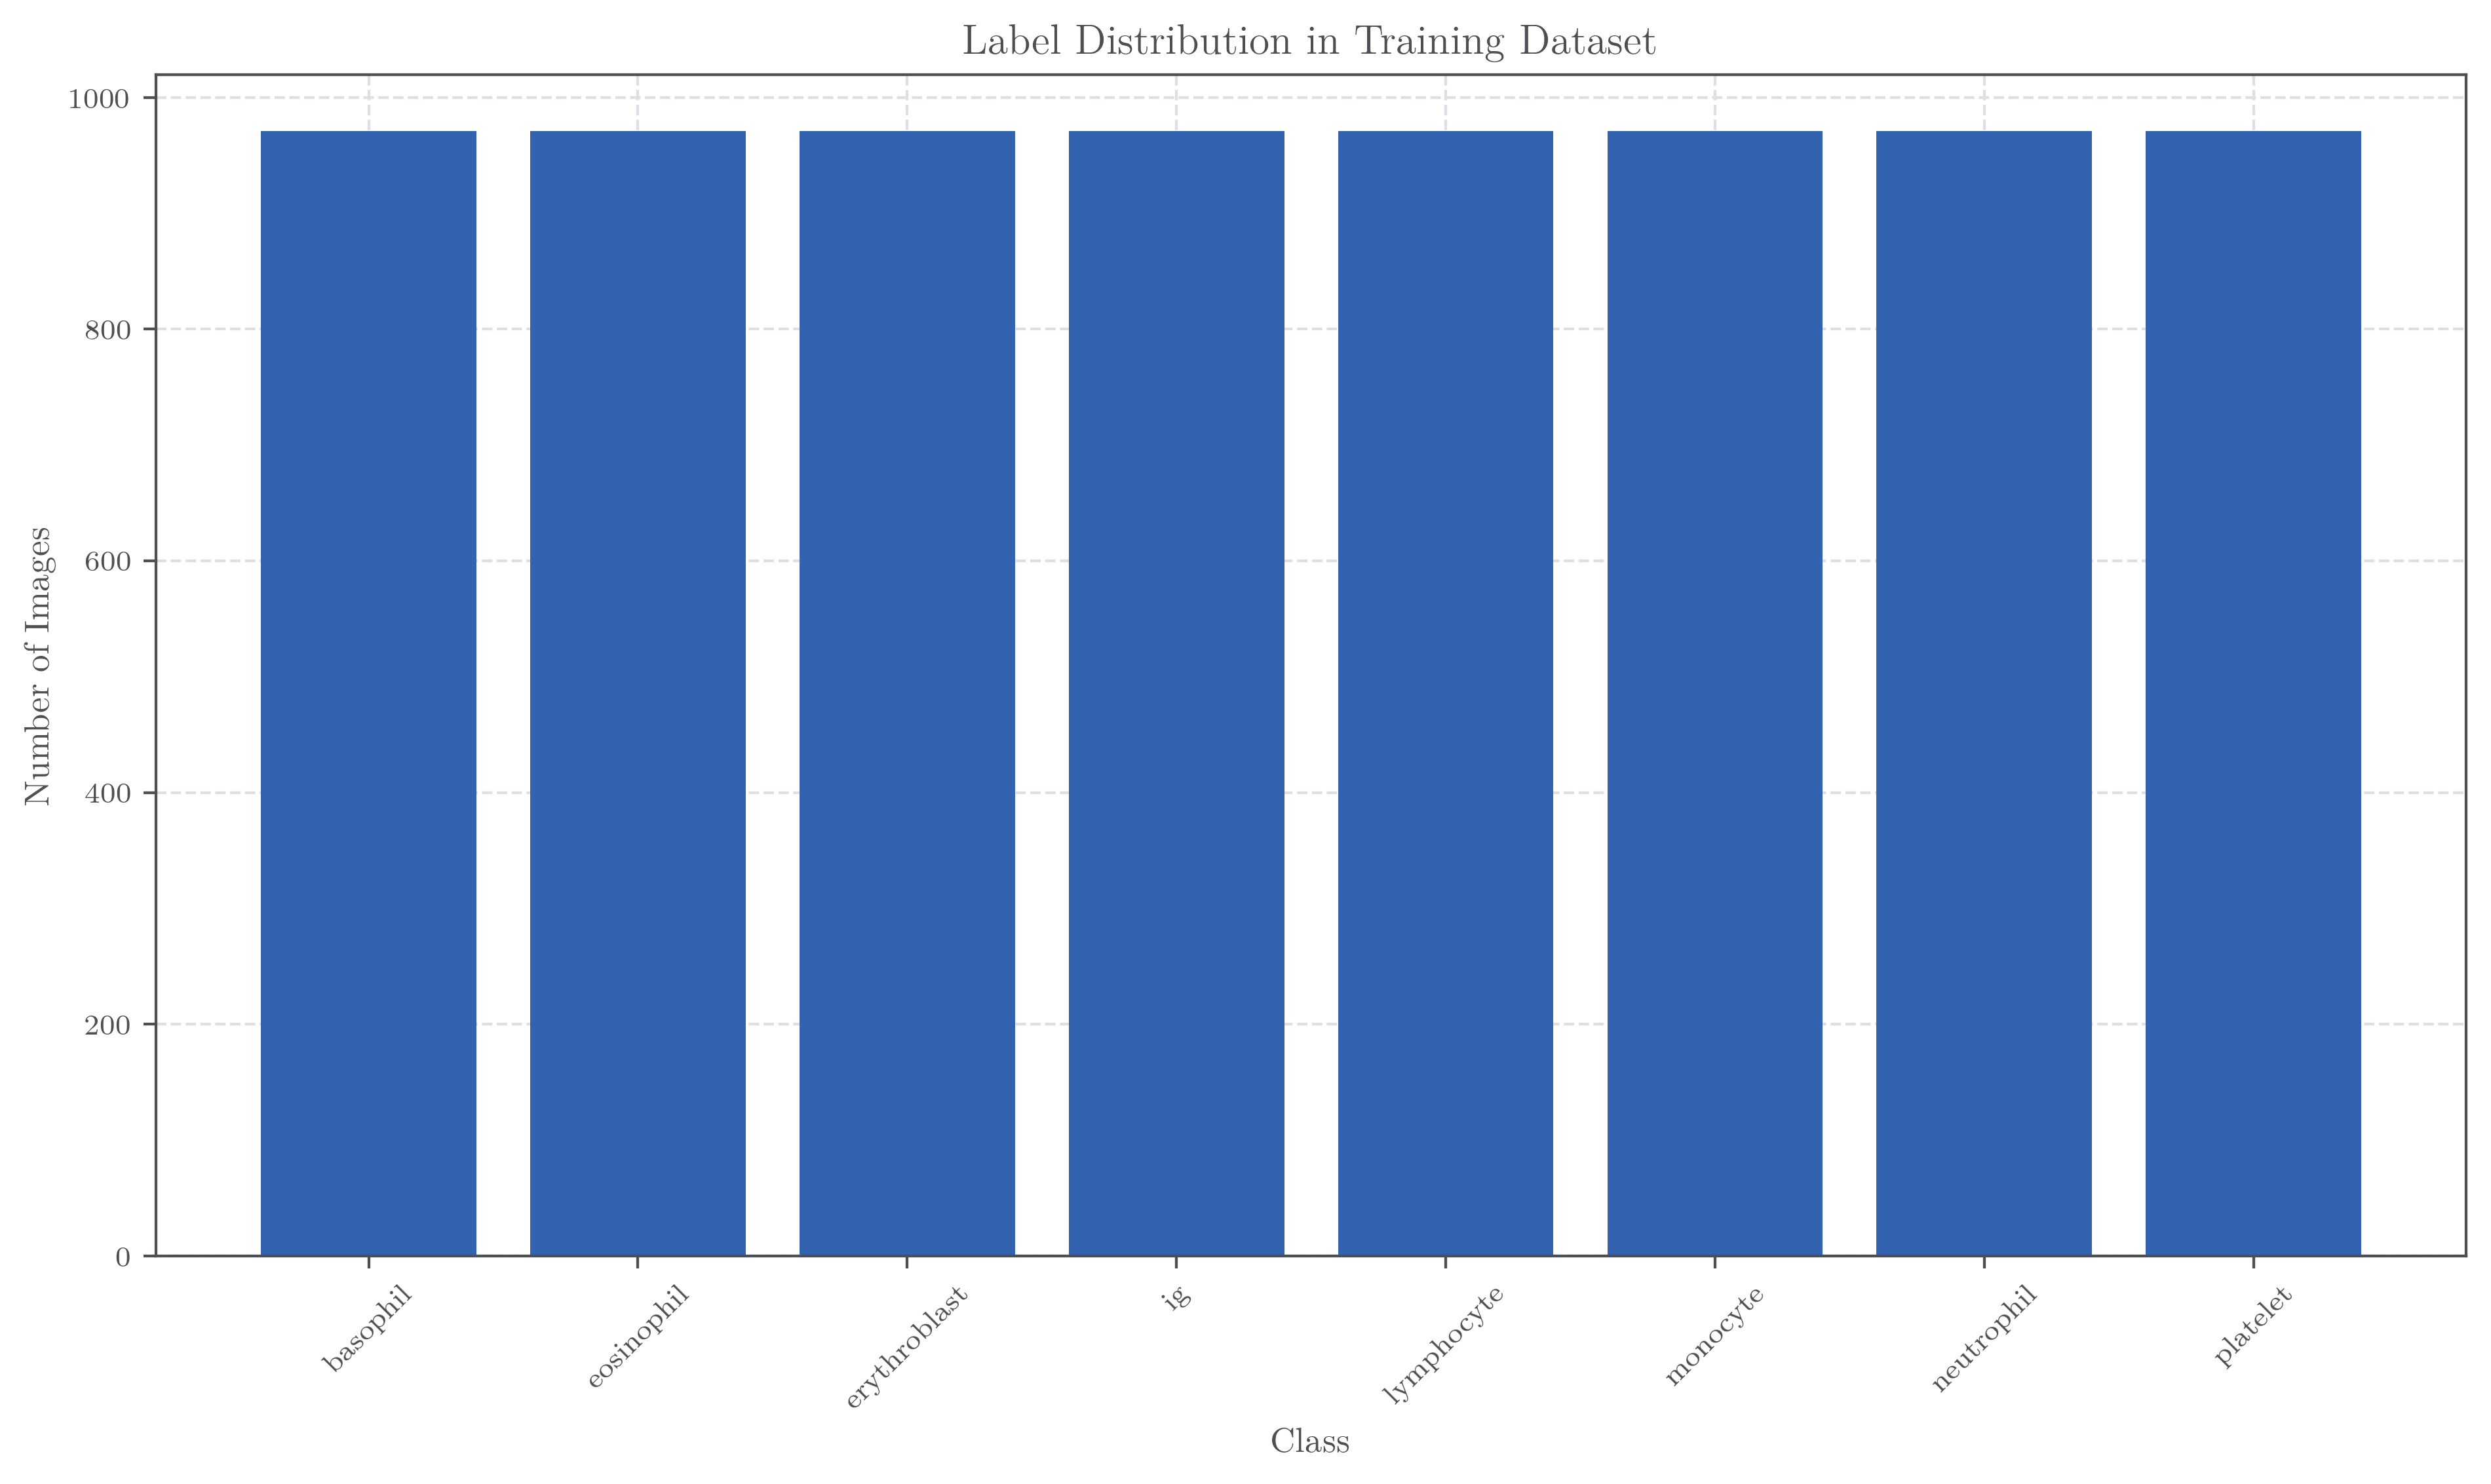

In [ ]:
pplt.use_style()
all_labels = []
for _, labels in balanced_ds:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

class_names = balanced_ds.class_names
sorted_labels = sorted(label_counts.items())

labels, counts = zip(*sorted_labels)
label_names = [class_names[i] for i in labels]

plt.figure(figsize=(10, 6))
plt.bar(label_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Label Distribution in Training Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
val_ds=image_dataset_from_directory('./val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')
class_names=val_ds.class_names
print(class_names)

Found 3421 files belonging to 8 classes.
['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [21]:
#preprocessing the oversampled data
train_ds=balanced_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))

In [11]:
base_model=VGG16(weights='imagenet',include_top=False)
base_model.trainable=False
inputs=Input(shape=(363,360,3))
x=RandomRotation(0.1)(inputs)
x=RandomTranslation(height_factor=0.1,width_factor=0.1)(x)
x=RandomZoom(0.1)(x)
x=RandomFlip('horizontal')(x)
x=Resizing(64,64)(x)
x=Rescaling(1/255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

In [12]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=5)

Epoch 1/5


486/486 ━━━━━━━━━━━━━━━━━━━━ 184s 368ms/step - accuracy: 0.4457 - loss: 1.4572 - val_accuracy: 0.6977 - val_loss: 0.8122
Epoch 2/5
486/486 ━━━━━━━━━━━━━━━━━━━━ 190s 390ms/step - accuracy: 0.6416 - loss: 0.9528 - val_accuracy: 0.6323 - val_loss: 0.9466
Epoch 3/5
486/486 ━━━━━━━━━━━━━━━━━━━━ 179s 367ms/step - accuracy: 0.6749 - loss: 0.8756 - val_accuracy: 0.7091 - val_loss: 0.7808
Epoch 4/5
486/486 ━━━━━━━━━━━━━━━━━━━━ 245s 503ms/step - accuracy: 0.6995 - loss: 0.8137 - val_accuracy: 0.7135 - val_loss: 0.7548
Epoch 5/5
486/486 ━━━━━━━━━━━━━━━━━━━━ 195s 400ms/step - accuracy: 0.7145 - loss: 0.8034 - val_accuracy: 0.7331 - val_loss: 0.7118


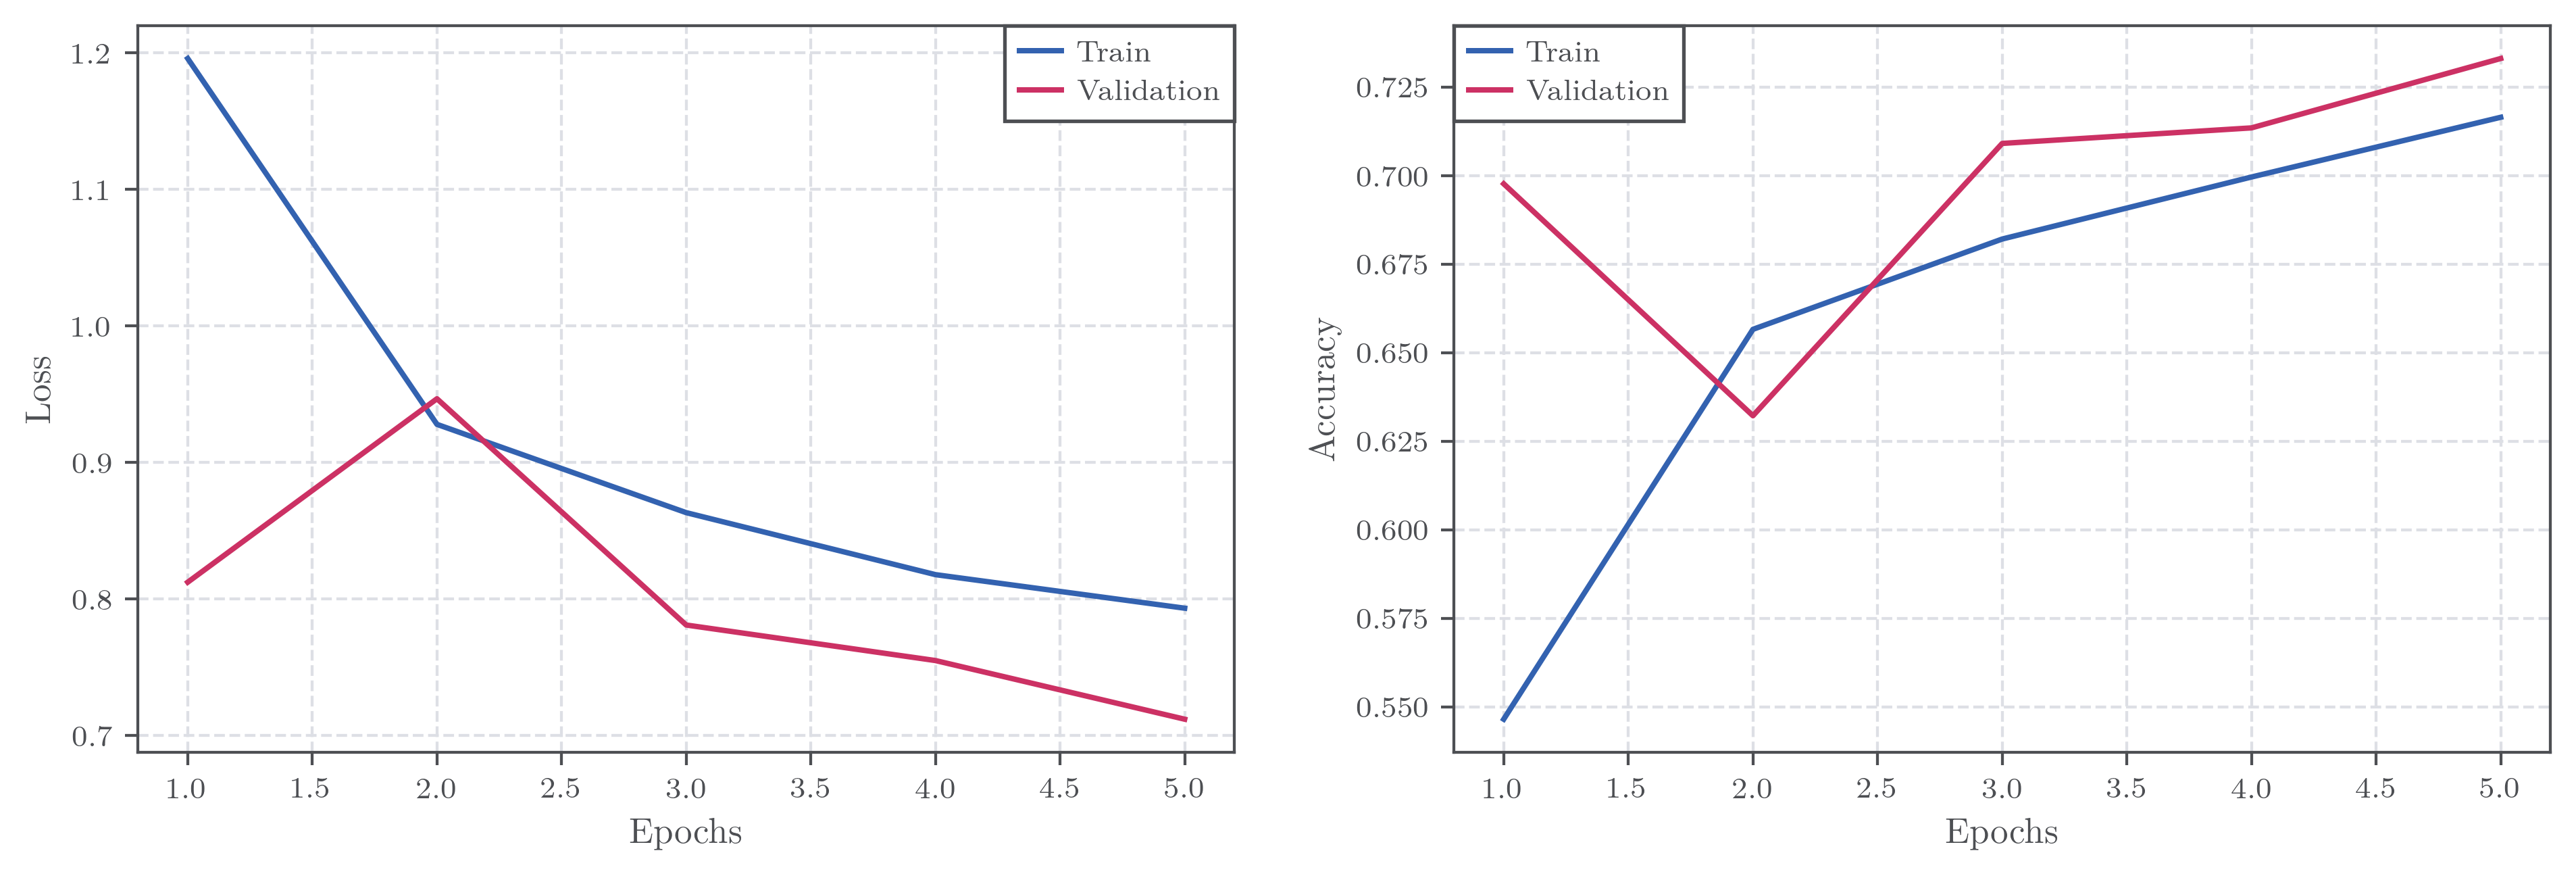

In [14]:
loss=history_model.history['loss']
val_loss=history_model.history['val_loss']
accuracy=history_model.history['accuracy']
val_accuracy=history_model.history['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(1,6),loss,label='Train')
plt.plot(np.arange(1,6),val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(1,6),accuracy,label='Train')
plt.plot(np.arange(1,6),val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [15]:
model.save("third_model_vgg16_undersampling.h5")

In [5]:
model = load_model("third_model_vgg16_undersampling.h5")

In [10]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(val_ds)

In [22]:
print(class_names)
print(classification_report(y_true, y_pred, target_names=class_names))

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
              precision    recall  f1-score   support

    basophil       0.47      0.80      0.59       244
  eosinophil       0.93      0.68      0.78       624
erythroblast       0.61      0.81      0.69       311
          ig       0.66      0.57      0.61       579
  lymphocyte       0.83      0.63      0.72       243
    monocyte       0.47      0.57      0.52       284
  neutrophil       0.86      0.88      0.87       666
    platelet       0.97      0.87      0.92       470

    accuracy                           0.73      3421
   macro avg       0.72      0.73      0.71      3421
weighted avg       0.77      0.73      0.74      3421



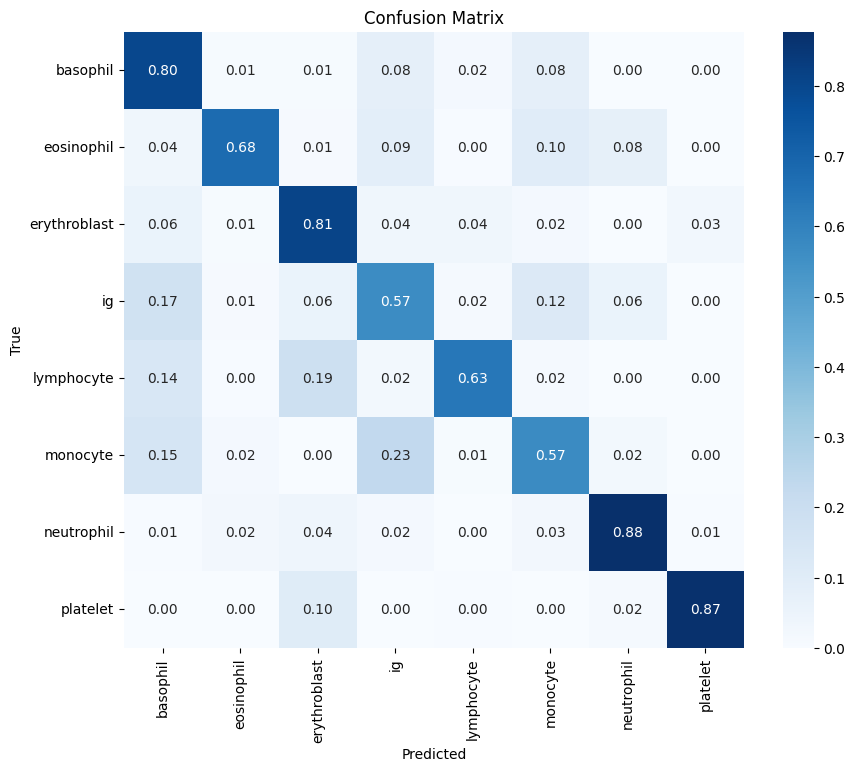

In [23]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()